In [1]:
!pip install kmapper
import kmapper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 5.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_csv("C:/Users/USER/Downloads/Project2/Project2/noisy_annuli_bridge.csv")
print(df.head())
print(df.tail())

          x         y  label     component
0 -6.617106  1.625012      0  left_annulus
1 -2.509268 -0.798896      0  left_annulus
2 -5.311963 -2.902399      0  left_annulus
3 -7.204998 -1.622039      0  left_annulus
4 -3.461512  2.383244      0  left_annulus
             x         y  label      component
2995  6.570730 -1.820943      2  right_annulus
2996  6.329019  2.009349      2  right_annulus
2997  4.111679  2.261858      2  right_annulus
2998  4.435125  2.474943      2  right_annulus
2999  6.527149 -1.591370      2  right_annulus


In [ ]:
df.shape

(3000, 4)

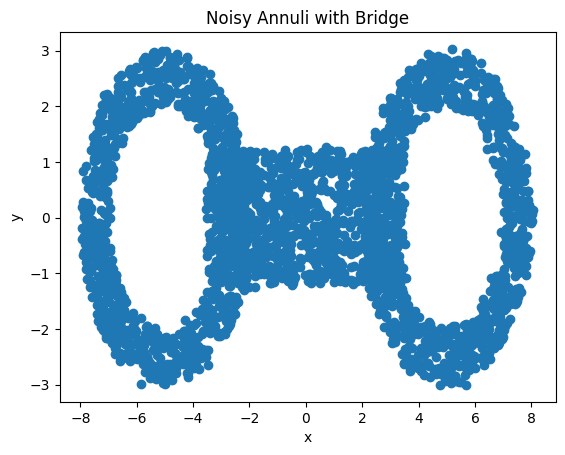

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = df.select_dtypes(include=[np.number]).values

# Visualizing Data
plt.scatter(X[:,0], X[:,1])
plt.title("Noisy Annuli with Bridge")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

def mapper_algorithm(X, lens_values, n_intervals, overlap_fraction, eps, min_samples):

    a = np.min(lens_values)
    b = np.max(lens_values)

    #Calculating interval length (l) and shift (s)
    l = (b - a) / (n_intervals - (n_intervals - 1) * overlap_fraction)
    s = (1 - overlap_fraction) * l

    #Initializing empty sets
    vertices = []
    edges = []

    #Loop through each cover element
    for k in range(n_intervals):
        #Defining interval boundaries
        u_start = a + k * s
        u_end = u_start + l

        #Computing pullback Xi
        xi_indices = np.where((lens_values >= u_start) & (lens_values <= u_end))[0]

        if len(xi_indices) == 0:
            continue

        #Clustering Xi using DBSCAN
        xi_data = X[xi_indices]
        clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(xi_data)
        labels = clustering.labels_

        unique_labels = set(labels) - {-1} # -1 is noise in DBSCAN
        for label in unique_labels:
            cluster_member_indices = set(xi_indices[labels == label])
            vertices.append(cluster_member_indices) #each cluster becomes a vertex

    num_vertices = len(vertices)
    for i in range(num_vertices):
        for j in range(i + 1, num_vertices):  #comparing clusters exactly once

            if not vertices[i].isdisjoint(vertices[j]):
                edges.append((i, j)) #adding an edge

    return vertices, edges   #Graph G=(V,E)

print("Mapper Algorithm Implemented Successfully.")

Mapper Algorithm Implemented Successfully.


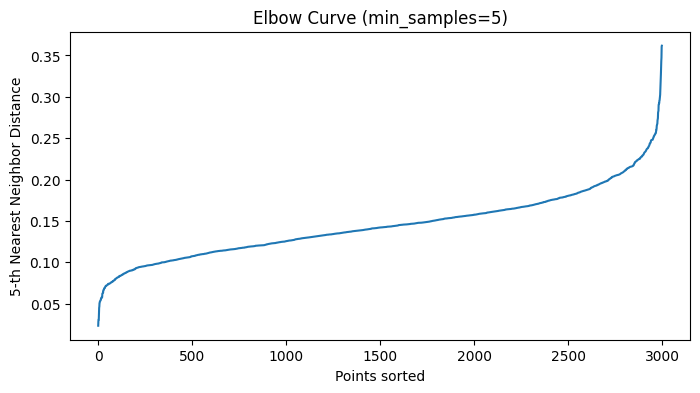

In [ ]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, _ = neighbors_fit.kneighbors(X)

#Sorting distances to the k-th neighbor
k_distances = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title(f"Elbow Curve (min_samples={min_samples})")
plt.ylabel(f"{min_samples}-th Nearest Neighbor Distance")
plt.xlabel("Points sorted")
plt.show()


In [ ]:
# Choosing Lens
lens_values = np.linalg.norm(X, axis=1)

# Mapper
vertices, edges = mapper_algorithm(
    X,
    lens_values,
    n_intervals=12,
    overlap_fraction=0.2,
    eps=0.23,
    min_samples=5
)

print("Number of vertices:", len(vertices))
print("Number of edges:", len(edges))

Number of vertices: 53
Number of edges: 51


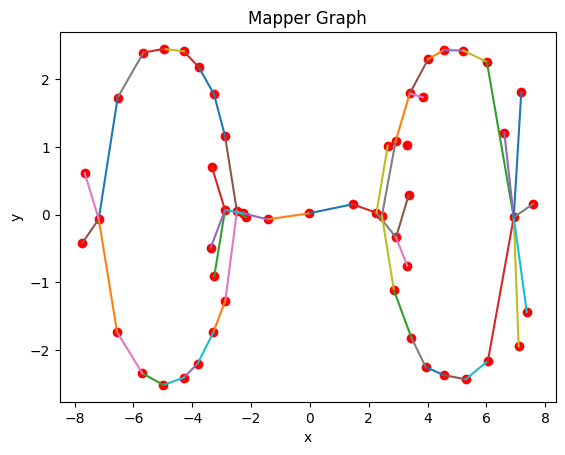

In [ ]:
#Ploting Mapper Graph
# Computing positions (centroid of each cluster)
positions = []
for v in vertices:
    pts = X[list(v)]
    positions.append(np.mean(pts, axis=0))

positions = np.array(positions)

# Plotting nodes
plt.scatter(positions[:,0], positions[:,1], color='red')

# Plotting edges
for i, j in edges:
    plt.plot(
        [positions[i][0], positions[j][0]],
        [positions[i][1], positions[j][1]]
    )

plt.title("Mapper Graph")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

The nodes represent the cluster of similar points. DBSCAN was used to group points that lie in the same density region.
The lines between nodes represent continuity. Because the slices overlapped, an edge tells us that the data flows smoothly from one region to the next.
By applying the Mapper Algorithm, we successfully compressed a noisy dataset of 3,000 points into a topological graph that clearly identifies two distinct loops connected by a bridge, accurately recovering the underlying structure of the data."

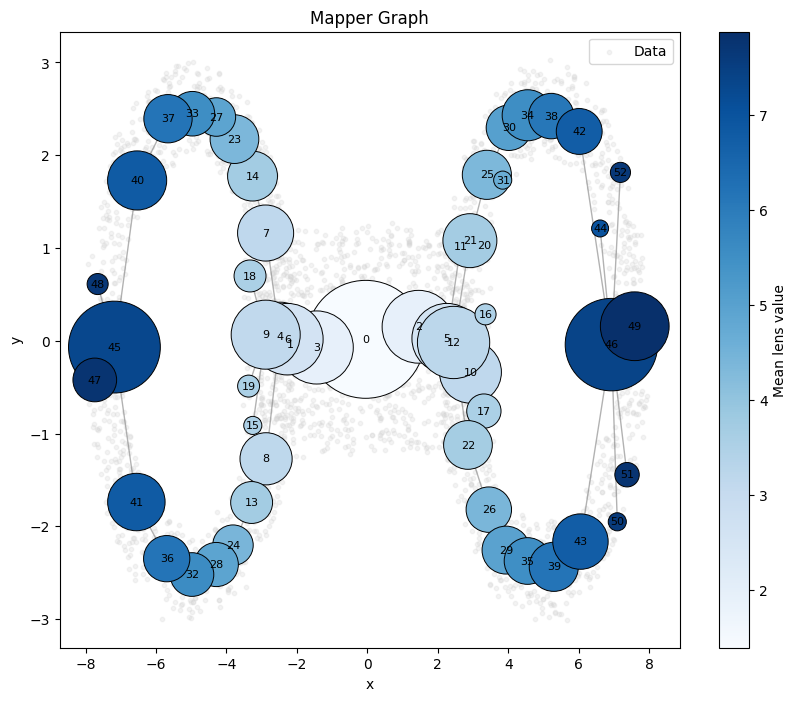

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

if {"x", "y"}.issubset(df.columns):
    X_plot = df[["x", "y"]].values
else:
    X_plot = X[:, :2]

if len(vertices) == 0:
    print("No Mapper vertices to display.")
else:

    positions = []
    node_sizes = []
    node_colors = []

    for v in vertices:
        idx = list(v)
        pts = X_plot[idx]

        positions.append(np.mean(pts, axis=0))


        node_sizes.append(len(idx))

        node_colors.append(np.mean(lens_values[idx]))

    positions = np.array(positions)
    node_sizes = np.array(node_sizes)
    node_colors = np.array(node_colors)

    plt.figure(figsize=(10, 8))

    plt.scatter(
        X_plot[:, 0], X_plot[:, 1],
        s=10, alpha=0.25, color="lightgray", label="Data"
    )

    for i, j in edges:
        plt.plot(
            [positions[i, 0], positions[j, 0]],
            [positions[i, 1], positions[j, 1]],
            color="gray", alpha=0.6, linewidth=1
        )

    sc = plt.scatter(
        positions[:, 0], positions[:, 1],
        c=node_colors,
        s=50 + 20 * node_sizes,   # taille proportionnelle à la taille du cluster
        cmap="Blues",             # proche de notebook 1
        edgecolors="black",
        linewidths=0.7,
        zorder=3
    )


    for k, (x, y) in enumerate(positions):
        plt.text(x, y, str(k), fontsize=8, ha="center", va="center", color="black")

    cbar = plt.colorbar(sc)
    cbar.set_label("Mean lens value")

    plt.title("Mapper Graph")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()